# Preparação e análise de Dados em Python

Nesta aula, aprenderemos um pouco a como entender melhor um conjunto de dados. Nos tempos atuais, é cada vez mais fácil conseguir quantidades cada vez maiores de dados. Contudo, isto vem com um custo: quanto mais dados, mais difícil é de **entender** os mesmos.

Hoje, aprenderemos a utilizar a biblioteca Pandas para manipular dados.


In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
#!pip3 install pandas --user

Na aula de hoje, usaremos uma base de dados sobre número de vendas de jogos de videogame até 2016. Nosso objetivo é entender melhor os dados para na sequência produzir modelos de regressão que melhor prevejam os números de vendas. Baixe o arquivo que está no Colabweb e coloque-o descomprimido na mesma pasta em que está rodando este notebook:


In [2]:
vg = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv')

O Pandas é uma biblioteca de manipulação de dados. A função read_csv lê **todo** conteúdo do arquivo e coloca em uma estrutura de dados. Existem funções similares para diversos tipos de arquivos, como `xls` e `json`.

Agora vamos visualizar o conteúdo dos nossos dados. Para isto, usaremos a função head, que mostra os 5 primeiros registros:


In [3]:
# vg.head()
# vg.tail()
vg.sample(5)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
14921,Last Escort 2: Shinya no Amai Toge,PS2,2008.0,Adventure,D3Publisher,0.00,0.00,0.03,0.00,0.03,NaN,NaN,NaN,NaN,NaN,NaN
5313,Chicken Shoot,Wii,2007.0,Action,Zoo Digital Publishing,0.32,0.00,0.00,0.02,0.35,27.0,9.0,4.8,26.0,Destination Software,E10+
16087,Blackthorne,GBA,2003.0,Action,Activision,0.01,0.00,0.00,0.00,0.01,67.0,10.0,7.6,5.0,Mass Media,T
14113,Fushigi no Dungeon: Fuurai no Shiren 5 - Fortu...,DS,2010.0,Role-Playing,ChunSoft,0.00,0.00,0.04,0.00,0.04,NaN,NaN,NaN,NaN,NaN,NaN
15362,Kill.Switch,GBA,2004.0,Shooter,Zoo Digital Publishing,0.02,0.01,0.00,0.00,0.02,NaN,NaN,NaN,NaN,Visual Impact,T


In [4]:
vg.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='str')

In [5]:
vg.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       7590 non-null   float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(10), str(6)
memory usage: 2.0 MB


Acessando os dados de um jogo especifico:


In [6]:
# vg.loc[130]
vg2 = vg.loc[[1, 5, 10, 20]]
vg2
# vg.loc[0:100]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
10,Nintendogs,DS,2005.0,Simulation,Nintendo,9.05,10.95,1.93,2.74,24.67,NaN,NaN,NaN,NaN,NaN,NaN
20,Pokemon Diamond/Pokemon Pearl,DS,2006.0,Role-Playing,Nintendo,6.38,4.46,6.04,1.36,18.25,NaN,NaN,NaN,NaN,NaN,NaN


Podemos também acessar colunas especificas através dos seus nomes:


In [7]:
vg[['Name', 'Critic_Score']]

# vg.Global_Sales

,Name,Critic_Score
0,Wii Sports,76.0
1,Super Mario Bros.,NaN
2,Mario Kart Wii,82.0
3,Wii Sports Resort,80.0
4,Pokemon Red/Pokemon Blue,NaN
...,...,...
16714,Samurai Warriors: Sanada Maru,NaN
16715,LMA Manager 2007,NaN
16716,Haitaka no Psychedelica,NaN
16717,Spirits & Spells,NaN


Quantos jogos para cada sistema nós temos?


<Axes: xlabel='Genre'>

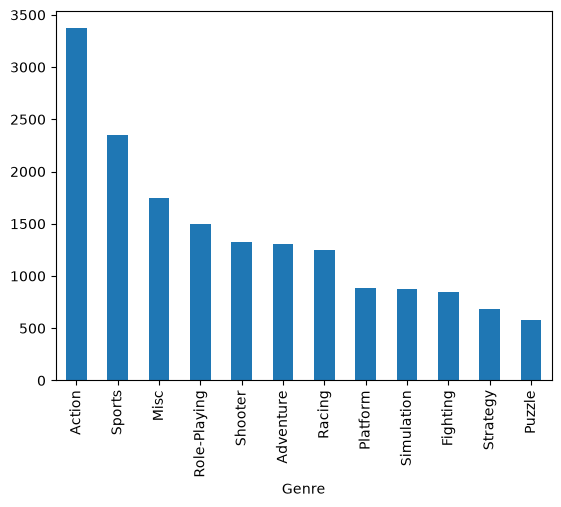

In [8]:
vg.Genre.value_counts().plot(kind='bar')

Contando a quantidade de valores diferentes de um atributo numérico:


In [9]:
vg.Critic_Score.value_counts()

Critic_Score
70.0    256
71.0    254
75.0    245
78.0    240
73.0    238
       ... 
20.0      3
21.0      1
17.0      1
22.0      1
13.0      1
Name: count, Length: 82, dtype: int64

Muito né? melhor seria colocar em categorias:


In [10]:
b = list(range(0, 101, 10))
b
vg.Critic_Score.value_counts(bins=b)

(70.0, 80.0]      2344
(60.0, 70.0]      1949
(80.0, 90.0]      1518
(50.0, 60.0]      1188
(40.0, 50.0]       571
(90.0, 100.0]      257
(30.0, 40.0]       236
(20.0, 30.0]        63
(10.0, 20.0]        11
(-0.001, 10.0]       0
Name: count, dtype: int64

O Pandas oferece vários métodos para entender melhor os dados com estatísticas básicas:


In [11]:
vg.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,7.125046,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,1.500006,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.500000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,8.200000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


Epa! Tem um jogo com lançamento em 2020! Não pode, pois a base é de jogos lançados até 2016. Na verdade, isso é super comum com dados reais, de haver sujeira na base de dados.

E agora, como podemos identificar que jogo é esse ?


In [12]:
# vg[vg.Year_of_Release == 2020]
vg.loc[vg.Year_of_Release == 2020, ['Year_of_Release']] = [2009]

Conseguiu entender como funcionou? Brinque um pouco com os dados para entender melhor.

Quais são os jogos mais recentes da base para Nintendo Wii?


In [13]:
# vg[vg.Platform == 'Wii']
vg[vg.Platform == 'Wii'].sort_values(
    ['Year_of_Release', 'Global_Sales'], ascending=False).head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
8010,Just Dance 2017,Wii,2016.0,Misc,Ubisoft,0.06,0.11,0.0,0.01,0.18,NaN,NaN,NaN,NaN,Ubisoft Paris,E10+
2179,Just Dance 2016,Wii,2015.0,Misc,Ubisoft,0.41,0.46,0.0,0.08,0.95,NaN,NaN,NaN,NaN,Ubisoft,E10+
8942,Skylanders: SuperChargers,Wii,2015.0,Action,Activision,0.02,0.12,0.0,0.01,0.15,NaN,NaN,NaN,NaN,NaN,NaN
14684,Barbie and Her Sisters Puppy Rescue,Wii,2015.0,Action,Namco Bandai Games,0.00,0.03,0.0,0.00,0.03,NaN,NaN,NaN,NaN,"Torus Games, Little Orbit",E
16315,Monster High: New Ghoul in School,Wii,2015.0,Action,Little Orbit,0.00,0.01,0.0,0.00,0.01,NaN,NaN,NaN,NaN,"Torus Games, Little Orbit",E
850,Just Dance 2015,Wii,2014.0,Misc,Ubisoft,0.99,0.85,0.0,0.17,2.01,NaN,NaN,8.4,5.0,Ubisoft,E10+
2180,Skylanders: Trap Team,Wii,2014.0,Action,Activision,0.41,0.46,0.0,0.08,0.95,NaN,NaN,NaN,NaN,Toys for Bob,E10+
3611,FIFA 15,Wii,2014.0,Sports,Electronic Arts,0.15,0.37,0.0,0.04,0.56,NaN,NaN,4.3,12.0,EA Sports,E
7992,How to Train Your Dragon 2,Wii,2014.0,Adventure,Little Orbit,0.04,0.13,0.0,0.01,0.18,NaN,NaN,NaN,NaN,Torus Games,E10+
13571,Disney Planes Fire & Rescue,Wii,2014.0,Action,Disney Interactive Studios,0.00,0.04,0.0,0.00,0.04,NaN,NaN,NaN,NaN,NaN,NaN


A saída de boa parte de comandos em Pandas gera objetos do tipo dataframe ou series. Estes objetos novos podem ser utilizados com outras funções pandas, em cascata.

Isto são condições compostas

Jogos de PS3 que tiveram mais do que 20 críticas ordenados pela nota da critica:


In [14]:
# vg[(vg.Platform == 'PS2')][(vg.Critic_Count > 20)
#                            ].sort_values(['Critic_Score']).head()
vg[(vg.Platform == 'PS3') & (vg.Critic_Count > 20)
   ].sort_values(['Critic_Score']).head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
9337,Rogue Warrior,PS3,2009.0,Shooter,Bethesda Softworks,0.11,0.01,0.00,0.01,0.13,27.0,24.0,2.8,66.0,Rebellion,M
7513,Mobile Suit Gundam: Crossfire,PS3,2006.0,Simulation,Namco Bandai Games,0.06,0.00,0.14,0.01,0.20,33.0,31.0,5.1,47.0,Bec,T
11114,Damnation,PS3,2009.0,Shooter,Codemasters,0.07,0.01,0.00,0.01,0.09,36.0,36.0,2.8,40.0,Blue Omega,M
7581,Kung Fu Rider,PS3,2010.0,Action,Sony Computer Entertainment,0.06,0.09,0.01,0.03,0.20,36.0,45.0,3.7,21.0,SCE Japan Studio,E10+
4881,Harry Potter and the Deathly Hallows - Part 1,PS3,2010.0,Action,Electronic Arts,0.13,0.20,0.00,0.07,0.39,38.0,27.0,2.8,23.0,EA Bright Light,T
9095,Thor: God of Thunder,PS3,2011.0,Action,Sega,0.07,0.05,0.00,0.02,0.14,39.0,35.0,4.4,19.0,Liquid Entertainment,T
11818,Escape Dead Island,PS3,2014.0,Action,Deep Silver,0.04,0.03,0.00,0.01,0.07,40.0,25.0,3.5,51.0,Fatshark AB,M
4918,Iron Man 2,PS3,2010.0,Action,Sega,0.14,0.18,0.00,0.07,0.39,41.0,28.0,5.2,36.0,Sega Studios San Francisco,T
5770,Clash of the Titans,PS3,2010.0,Action,Namco Bandai Games,0.09,0.15,0.01,0.05,0.31,41.0,28.0,1.7,17.0,Game Republic,T
6808,Turning Point: Fall of Liberty,PS3,2008.0,Shooter,Codemasters,0.21,0.01,0.00,0.02,0.24,42.0,28.0,5.5,33.0,Spark Unlimited,T


Exercício 1:

1 - Gere uma base vg2, contendo todos os jogos lançados de 2000 a 2016 e a descreva com describe

2 - Mostre todos os jogos lançados até o ano 2000 onde as vendas japonesas foram acima das americanas, ordenado por vendas globais

3 - Conte, para cada plataforma, quantos jogos com nota de usuário acima de 8 cada uma tem


In [15]:
vg2 = vg[(vg.Year_of_Release >= 2000) & (vg.Year_of_Release <= 2016)]
vg2.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,14471.000000,14471.000000,14471.000000,14471.000000,14471.000000,14471.000000,7887.000000,7887.000000,7371.000000,7371.000000
mean,2008.022390,0.243928,0.144123,0.056376,0.050316,0.495017,68.858882,26.601750,7.110975,161.464523
std,4.111026,0.713231,0.513156,0.249715,0.198328,1.463375,13.869432,19.041747,1.498326,561.626621
min,2000.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2005.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,6.400000,10.000000
50%,2008.000000,0.080000,0.020000,0.000000,0.010000,0.160000,71.000000,22.000000,7.500000,24.000000
75%,2011.000000,0.230000,0.110000,0.030000,0.040000,0.440000,79.000000,37.000000,8.200000,81.000000
max,2016.000000,41.360000,28.960000,6.500000,10.570000,82.530000,98.000000,113.000000,9.700000,10665.000000


In [16]:
vg[(vg.JP_Sales > vg.NA_Sales) & (vg.Year_of_Release <= 2000)
   ].sort_values(['Global_Sales'], ascending=False).head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
65,Final Fantasy VII,PS,1997.0,Role-Playing,Sony Computer Entertainment,3.01,2.47,3.28,0.96,9.72,92.0,20.0,9.2,1282.0,SquareSoft,T
76,Super Mario Kart,SNES,1992.0,Racing,Nintendo,3.54,1.24,3.81,0.18,8.76,NaN,NaN,NaN,NaN,NaN,NaN
88,Final Fantasy VIII,PS,1999.0,Role-Playing,SquareSoft,2.28,1.72,3.63,0.23,7.86,90.0,24.0,8.6,644.0,SquareSoft,T
137,Street Fighter II: The World Warrior,SNES,1992.0,Fighting,Capcom,2.47,0.83,2.87,0.12,6.30,NaN,NaN,NaN,NaN,NaN,NaN
151,Resident Evil 2,PS,1998.0,Action,Virgin Interactive,1.88,1.47,2.02,0.45,5.82,89.0,13.0,9.2,364.0,Capcom,M
175,Final Fantasy IX,PS,2000.0,Role-Playing,SquareSoft,1.62,0.77,2.78,0.14,5.30,94.0,22.0,8.9,779.0,SquareSoft,T
191,Donkey Kong Country 2: Diddy's Kong Quest,SNES,1995.0,Platform,Nintendo,2.10,0.74,2.20,0.11,5.15,NaN,NaN,NaN,NaN,NaN,NaN
244,Dragon Quest VII: Warriors of Eden,PS,2000.0,Role-Playing,Enix Corporation,0.20,0.14,4.10,0.02,4.47,NaN,NaN,NaN,NaN,NaN,NaN
285,Super Mario World 2: Yoshi's Island,SNES,1995.0,Platform,Nintendo,1.65,0.61,1.76,0.09,4.12,NaN,NaN,NaN,NaN,NaN,NaN
287,Street Fighter II Turbo,SNES,1992.0,Fighting,Capcom,1.42,0.51,2.10,0.07,4.10,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
vg[vg.User_Score > 8].Platform.value_counts()

Platform
PS2     590
XB      275
PC      237
GC      164
X360    148
Wii     137
PS3     136
GBA     122
DS      116
PSP     100
PS       97
PSV      43
PS4      41
3DS      39
WiiU     21
XOne     21
DC       11
Name: count, dtype: int64

### Usando pandas para plotar com pyplot

Uma coisa legal no pandas é que ele é integrado ao pyplot/matplotlib.

Exemplo: Qual a relação entre as vendas globais e a nota da crítica?


<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

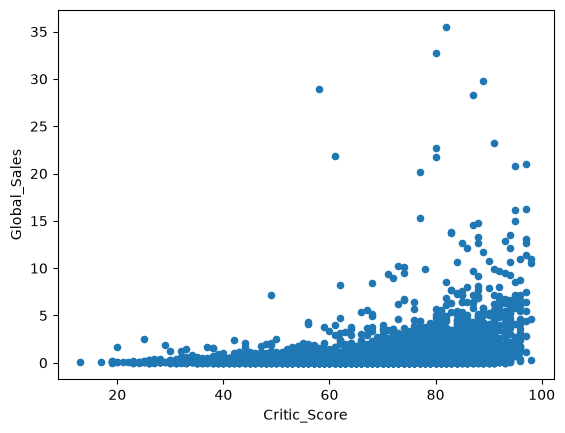

In [18]:
vg[vg.Global_Sales < 80].plot(
    kind='scatter', x='Critic_Score', y='Global_Sales')
# outlier
# vg[vg.Global_Sales>80]

Os valores muito altos (como o Wii Sports com 80 milhões de cópias), estão dificultando a visualização. Para resolver este problema, podemos ou eliminar estes valores do plot ou plotar em escala logaritmica:


<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

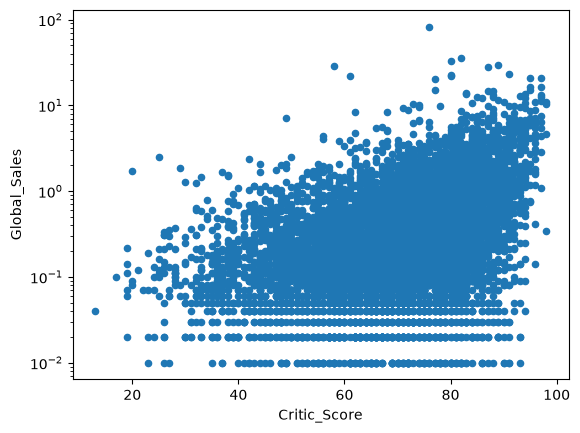

In [19]:
# vg[vg.Global_Sales<20].plot(kind='scatter',x='Critic_Score',y='Global_Sales')

vg.plot(kind='scatter', x='Critic_Score', y='Global_Sales', logy=True)

### Outras correlações mais sofisticadas

Como será a comparação entre as notas dos críticos para RPGs em comparação com jogos de corrida?


<Axes: >

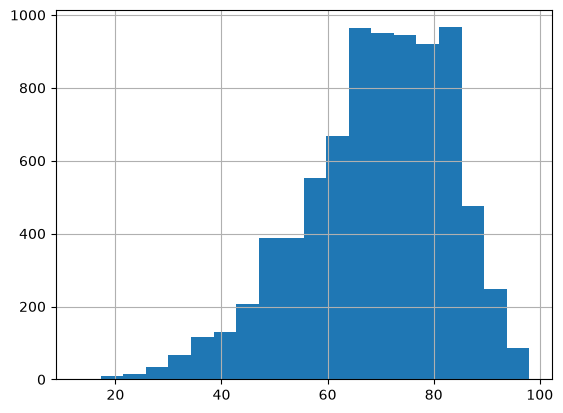

In [20]:
# Primeiro veremos o histograma global
vg.Critic_Score.hist(bins=20)

<Axes: >

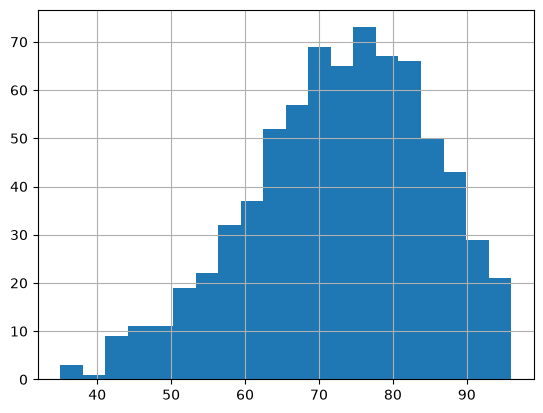

In [21]:
# Agora apenas dos RPGs
vg[vg.Genre == 'Role-Playing'].Critic_Score.hist(bins=20)

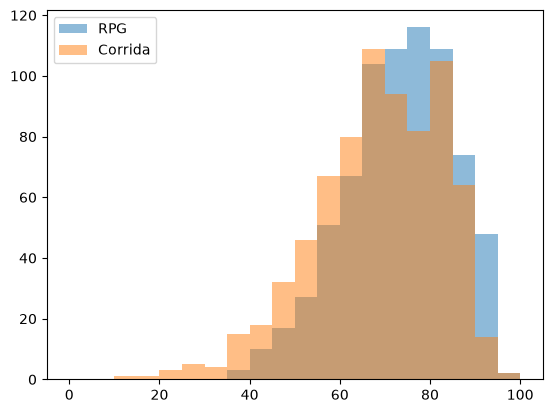

In [22]:
# Podemos comparar os RPGs com os jogos de corrida

bins = list(range(0, 101, 5))
# Remover os jogos sem valor de Critic_Score
vgval = vg[vg.Critic_Score.notnull()]

plt.hist(vgval[vgval.Genre == 'Role-Playing'].Critic_Score,
         bins, alpha=0.5, label='RPG')
plt.hist(vgval[vgval.Genre == 'Racing'].Critic_Score,
         bins, alpha=0.5, label='Corrida')
plt.legend()

E se eu quiser comparar variáveis categóricas?

Vamos analisar duas: Gênero e Plataforma.


In [23]:
pd.crosstab(vg.Platform, vg.Genre, margins=True)  # , normalize='index')

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy,All
Platform,,,,,,,,,,,,,
2600,61,2,2,5,9,11,6,0,24,1,12,0,133
3DO,0,1,0,0,0,1,0,0,0,1,0,0,3
3DS,188,38,14,54,28,20,11,88,7,31,26,15,520
DC,3,11,12,0,2,0,6,4,3,1,10,0,52
DS,340,238,36,391,91,236,67,200,42,284,148,79,2152
GB,6,5,0,8,19,15,2,21,1,5,9,7,98
GBA,167,38,23,110,142,41,64,73,40,18,88,18,822
GC,101,20,42,36,73,13,63,27,48,12,110,11,556
GEN,3,2,5,1,7,0,1,3,1,0,3,1,27


E se a gente quisesse esses valores em porcentagens? Podemos então aplicar uma **função lambda** nos dados:


In [24]:
# .apply(lambda v:100*v/v[-1],axis = 1) jeito escroto
pd.crosstab(vg.Platform, vg.Genre, margins=True, normalize='index')

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Platform,,,,,,,,,,,,
2600,0.458647,0.015038,0.015038,0.037594,0.067669,0.082707,0.045113,0.000000,0.180451,0.007519,0.090226,0.000000
3DO,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000
3DS,0.361538,0.073077,0.026923,0.103846,0.053846,0.038462,0.021154,0.169231,0.013462,0.059615,0.050000,0.028846
DC,0.057692,0.211538,0.230769,0.000000,0.038462,0.000000,0.115385,0.076923,0.057692,0.019231,0.192308,0.000000
DS,0.157993,0.110595,0.016729,0.181691,0.042286,0.109665,0.031134,0.092937,0.019517,0.131970,0.068773,0.036710
GB,0.061224,0.051020,0.000000,0.081633,0.193878,0.153061,0.020408,0.214286,0.010204,0.051020,0.091837,0.071429
GBA,0.203163,0.046229,0.027981,0.133820,0.172749,0.049878,0.077859,0.088808,0.048662,0.021898,0.107056,0.021898
GC,0.181655,0.035971,0.075540,0.064748,0.131295,0.023381,0.113309,0.048561,0.086331,0.021583,0.197842,0.019784
GEN,0.111111,0.074074,0.185185,0.037037,0.259259,0.000000,0.037037,0.111111,0.037037,0.000000,0.111111,0.037037


E se eu quiser uma tabela dessas, mas apenas contendo os jogos que venderam mais de 10 milhões de unidades?


In [25]:
pd.crosstab(vg[vg.Global_Sales > 10].Platform, vg[vg.Global_Sales >
            10].Genre, margins=True)  # ,normalize='index')

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,All
Platform,,,,,,,,,,,,
3DS,0,0,0,0,1,0,1,2,0,0,0,4
DS,1,0,0,1,2,1,1,2,0,2,0,10
GB,0,1,0,0,1,1,0,3,0,0,0,6
GBA,0,0,0,0,0,0,0,2,0,0,0,2
N64,0,0,0,0,1,0,0,0,0,0,0,1
NES,0,0,0,0,2,0,0,0,1,0,0,3
PS,0,0,0,0,0,0,1,0,0,0,0,1
PS2,3,0,0,0,0,0,2,0,0,0,0,5
PS3,2,0,0,0,0,0,1,0,4,0,0,7


## Tabelas Pivo

Muitas vezes, queremos cruzar dados de formas mais complexas. A tabela pivo ajuda muito nisso.

Exemplo: Quem teve os melhores RPGs e adventures de acordo com a crítica? O primeiro ou o segundo Playstation?


In [26]:
rpgs = vg[(vg.Platform.isin(['PS2', 'PS'])) &
          vg.Genre.isin(['Role-Playing', 'Adventure'])]
# rpgs.head()
# pivot = rpgs.pivot_table(values=['Critic_Score', "Global_Sales"], index=['Platform', 'Genre'], aggfunc=["mean", 'sum'])
pivot = rpgs.pivot_table(values=['Critic_Score'], index=[
                         'Platform', 'Genre'], aggfunc=["mean"])
pivot

mean
                      Critic_Score
Platform Genre                    
PS       Adventure       58.000000
         Role-Playing    79.428571
PS2      Adventure       62.348837
         Role-Playing    71.639344

<Axes: ylabel='Platform,Genre'>

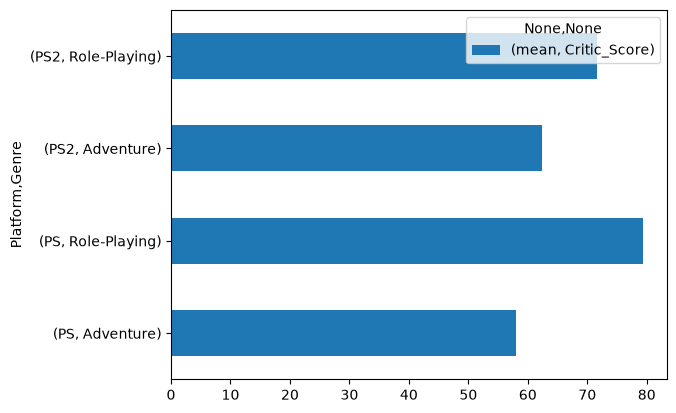

In [27]:
pivot.plot(kind='barh')

Exercício 2:

Faça uma tabela contendo a media das notas de usuários dos jogos das Publishers Capcom e Activision de acordo com o Rating


E se eu quiser saber quantas unidades o jogo mais vendido de cada plataforma vendeu?


In [28]:
# quantas unidades o jogo mais vendido de cada plataforma vendeu?
plats = vg[(vg.Platform.isin(['PS3', 'X360']))]

plats.pivot_table(values=['Global_Sales'], index=[
                  'Platform', 'Genre'], aggfunc=["max",])

max
                      Global_Sales
Platform Genre                    
PS3      Action              21.04
         Adventure            4.82
         Fighting             4.16
         Misc                 5.26
         Platform             5.82
         Puzzle               0.40
         Racing              10.70
         Role-Playing         6.41
         Shooter             13.79
         Simulation           1.94
         Sports               6.65
         Strategy             0.78
X360     Action              16.27
         Adventure            5.54
         Fighting             2.94
         Misc                21.81
         Platform             1.38
         Puzzle               0.32
         Racing               5.49
         Role-Playing         8.79
         Shooter             14.73
         Simulation           2.28
         Sports               6.19
         Strategy             2.62

## Agrupando

Você pode usar o comando groupby para gerar novas bases de dados modificadas. Por exemplo, você pode tentar prever as vendas totais de plataformas ao invés de jogos individuais. Contudo, para você utilizar os dados agrupados, você deve usar uma função de agregação (sum,count, min,max, mean, etc).

### Exemplo

Criando um agrupamento por plataforma


In [29]:
vgplat = vg.groupby(['Platform'])
vgplat.Global_Sales.sum()
# vgplat.Critic_Score.min()

Platform
2600      97.08
3DO        0.10
3DS      259.09
DC        15.97
DS       807.10
GB       255.45
GBA      318.50
GC       199.36
GEN       30.78
GG         0.04
N64      218.88
NES      251.07
NG         1.44
PC       260.30
PCFX       0.03
PS       730.68
PS2     1255.64
PS3      939.43
PS4      314.23
PSP      294.30
PSV       54.12
SAT       33.59
SCD        1.87
SNES     200.05
TG16       0.16
WS         1.42
Wii      908.13
WiiU      82.16
X360     971.63
XB       258.26
XOne     159.44
Name: Global_Sales, dtype: float64

Fazendo uma relação para descobrir total de vendas de um console pelo total de jogos lançados para ele:


Text(0.5, 1.0, 'Quantidade de jogos por plataforma x vendas globais')

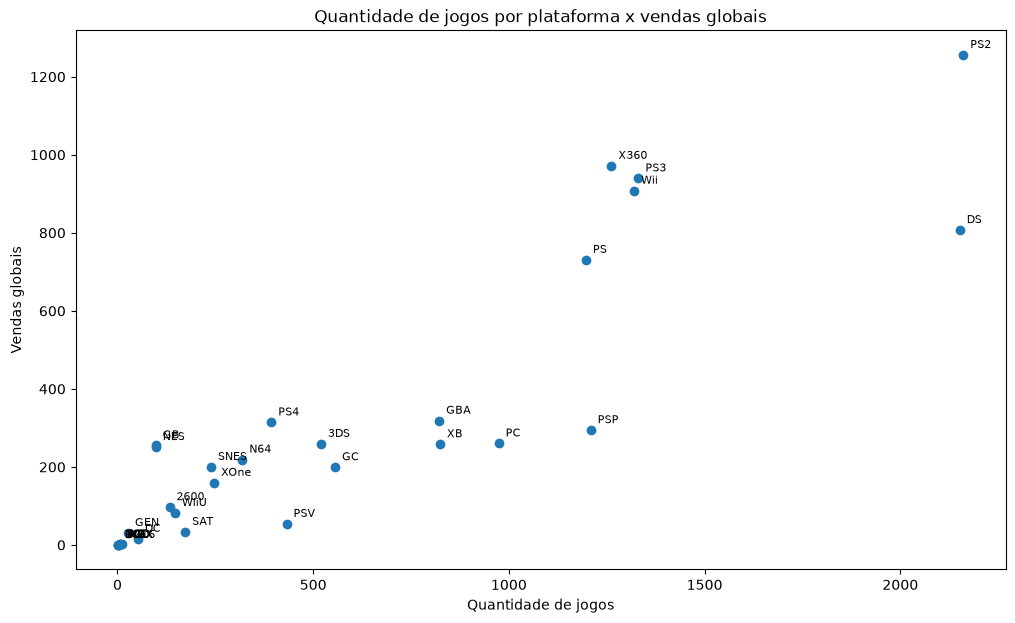

In [30]:
x = vgplat.Name.count()
y = vgplat.Global_Sales.sum()

plt.figure(figsize=(12, 7))
plt.scatter(x, y)

for plataforma in x.index:
    plt.annotate(plataforma, (x[plataforma], y[plataforma]),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.xlabel('Quantidade de jogos')
plt.ylabel('Vendas globais')
plt.title('Quantidade de jogos por plataforma x vendas globais')

<Axes: xlabel='Platform'>

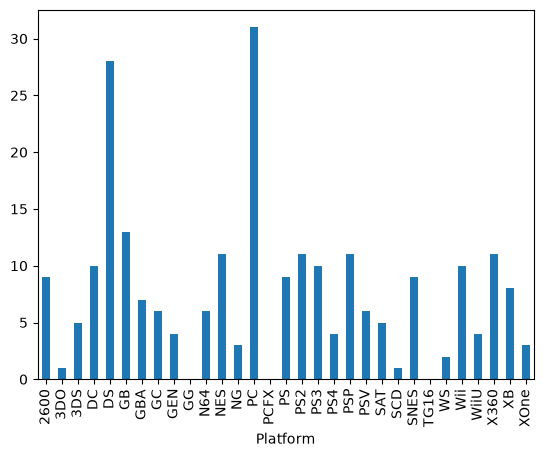

In [31]:
# Total de anos que um console teve jogos

anos = vgplat.Year_of_Release.max() - vgplat.Year_of_Release.min()
anos.plot(kind='bar')

Vocês poderiam usar a informação de ano para ponderar alguma outra informação usada na regressão por exemplo. Contudo, tem algo estranho né? O Nintendo DS está com 35 anos de jogos lançados. Vocês conseguem descobrir o porquê?
